In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import random

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
train=pd.read_csv('archive/sign_mnist_test.csv')
test=pd.read_csv('archive/sign_mnist_test.csv')
train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7167,1,135,119,108,102,105,99,61,103,121,...,108,112,116,114,118,180,184,176,167,163
7168,12,157,159,161,164,166,166,171,174,175,...,213,213,213,214,213,211,210,210,209,208
7169,2,190,191,190,191,190,190,192,192,191,...,216,215,213,214,214,213,210,211,209,208
7170,4,201,205,208,209,214,216,218,223,226,...,112,169,255,255,237,113,91,67,70,63


In [4]:
tungtungtung=tf.convert_to_tensor(train.drop('label',axis=1))
tungtungtung

2026-03-25 20:01:20.228383: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-03-25 20:01:20.228405: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-25 20:01:20.228408: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-03-25 20:01:20.228422: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-25 20:01:20.228431: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


<tf.Tensor: shape=(7172, 784), dtype=int64, numpy=
array([[149, 149, 150, ..., 112, 120, 107],
       [126, 128, 131, ..., 184, 182, 180],
       [ 85,  88,  92, ..., 225, 224, 222],
       ...,
       [190, 191, 190, ..., 211, 209, 208],
       [201, 205, 208, ...,  67,  70,  63],
       [173, 174, 173, ..., 195, 193, 192]])>

In [5]:
trainlabel= tf.convert_to_tensor(keras.utils.to_categorical(train['label']))
trainlabel.dtype

tf.float64

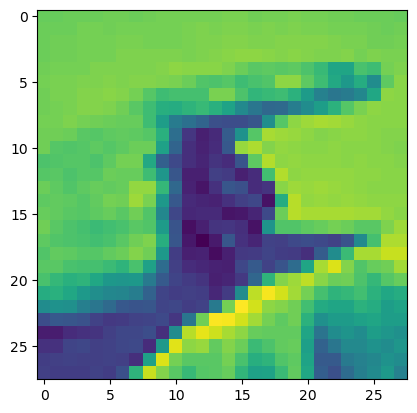

In [6]:
def show_img(ahihidongoc):
    ahihidongoc=tf.reshape(ahihidongoc,[-1,28,28])
    plt.imshow(ahihidongoc[0].numpy().astype("uint8"))
    plt.show()

show_img(tungtungtung)

In [7]:
minmax=MinMaxScaler()
tungtungtung=minmax.fit_transform(tungtungtung)
tungtungtung= tf.reshape(tungtungtung,[-1,28,28])
tungtungtung

<tf.Tensor: shape=(7172, 28, 28), dtype=float64, numpy=
array([[[0.58431373, 0.58431373, 0.58823529, ..., 0.58823529,
         0.58823529, 0.58431373],
        [0.58823529, 0.58823529, 0.58823529, ..., 0.59215686,
         0.58823529, 0.59215686],
        [0.58823529, 0.59215686, 0.59215686, ..., 0.59215686,
         0.59215686, 0.59607843],
        ...,
        [0.27058824, 0.27058824, 0.30196078, ..., 0.45490196,
         0.44313725, 0.4627451 ],
        [0.29019608, 0.29411765, 0.29803922, ..., 0.43137255,
         0.45490196, 0.44313725],
        [0.29411765, 0.29019608, 0.29019608, ..., 0.43921569,
         0.47058824, 0.41960784]],

       [[0.49411765, 0.50196078, 0.51372549, ..., 0.52156863,
         0.5254902 , 0.51764706],
        [0.50588235, 0.51764706, 0.5254902 , ..., 0.53333333,
         0.53333333, 0.5254902 ],
        [0.52156863, 0.52941176, 0.54117647, ..., 0.54901961,
         0.54509804, 0.54117647],
        ...,
        [0.67843137, 0.68235294, 0.69411765, ..., 0.

In [8]:
Alexnet=keras.Sequential([
    layers.InputLayer(shape=tungtungtung.shape),
    layers.Conv2D(64,kernel_size=(11,11), strides=(4,4),padding='same',activation='relu'),
    layers.MaxPool2D(pool_size=3,strides=(2,2)),
    layers.Conv2D(128,kernel_size=(5,5), strides=(1,1),padding='same',activation='relu'),
    layers.MaxPool2D(pool_size=3,strides=(2,2)),
    layers.Conv2D(256,kernel_size=(3,3), strides=(1,1),padding='same',activation='relu'),
    layers.Conv2D(128,kernel_size=(3,3), strides=(1,1),padding='same',activation='relu'),
    layers.Conv2D(64,kernel_size=(3,3), strides=(1,1),padding='same',activation='relu'),
    layers.MaxPool2D(pool_size=3,strides=(2,2)),
    layers.Flatten(),
    layers.Dense(4096,activation='relu'),
    layers.Dense(4096,activation='relu'),
    layers.Dense(24,activation='softmax')
])